In [3]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM


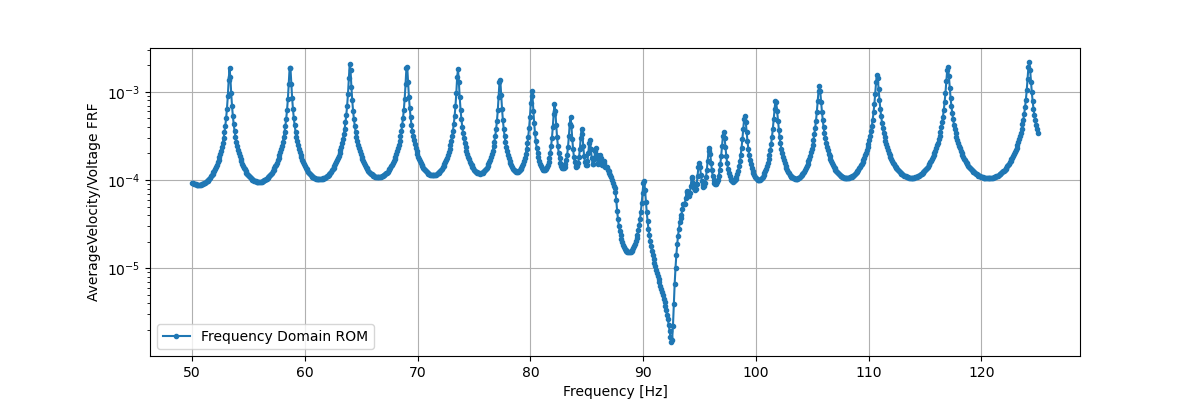

In [ ]:
import matplotlib.pyplot as plt
Q = 300
params = PiezoBeamParams( 
    Q = Q, L_b=3.185
    )
params.zeta_p = 0.0151/100
params.zeta_q = 0.0392/100
rom = ROM(params, N=40)


#%%
x_eval = np.linspace(0, rom.p.L_b, 500)

K_i = 4; K_p = 0.00002; K_c = 0

f0 = 50; f1 = 125
N = 40
j_exc = 299
freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
										w=np.linspace(f0, f1, 200)*2*np.pi, x_eval=x_eval)
# %matplotlib widget
plt.figure(figsize=(12, 4))
# plt.semilogy(frq_linear_exp, np.mean(frf_data_linear_exp[:,:], axis=1), 'r--', label=' Experiment')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w']*2*pi*comsol_OC['freq'], 'g-', label='COMSOL ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC_exp, np.mean(frf_data_SC_exp[:,:], axis=1), 'b--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
# plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM'   )
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Experiment')
# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')

# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )
plt.legend()
# plt.xlim([1300, 3000])
# plt.xlim([f0, f1])
# plt.ylim([1e-5, 1e-3])
# plt.ylim([3e-5, 6e-4])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()



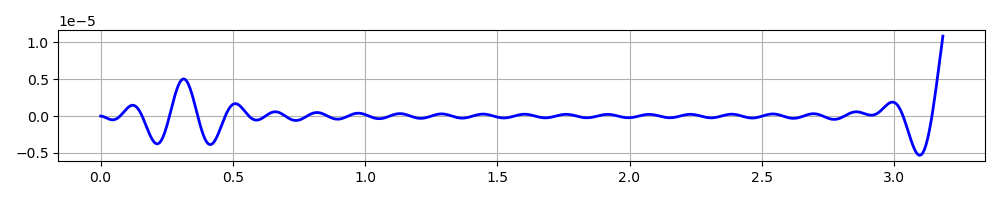

ki0=  4000 beta=  -0.3 f_target=  [78]


In [27]:

# =================== Mode shape at single frequency ===================
single_freq = np.array([78])
  # Hz - choose your frequency of interest
single_w = single_freq * 2 * np.pi
x_eval_mode = np.linspace(0, rom.p.L_b, 500)

# Get frequency response at single frequency
freq_single, vel_mag_single, disp_mag_single, veloc_frq = rom.frequency_response(
    K_c=K_c, K_p=K_p, K_i=K_i, w=single_w, x_eval=x_eval_mode
)

# veloc_frq has shape (n_spatial_points, 1) - extract the mode shape

# Plot the mode shape
plt.figure(figsize=(10, 2))
plt.plot(x_eval_mode,  veloc_frq[:, 0], 'b-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Velocity magnitude [m/s]')
# plt.title(f'Mode shape at {single_freq} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
# %%
print("ki0= ", ki0, 'beta= ', beta, 'f_target= ', single_freq)

K_i: [8163.26530612 2366.86390533 8163.26530612 2366.86390533 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 2366.86390533 8163.26530612 2366.86390533 8163.26530612 2366.86390533
 8163.26530612 2366.86390533 8163.26530612 2366.86390533 8163.26530612
 

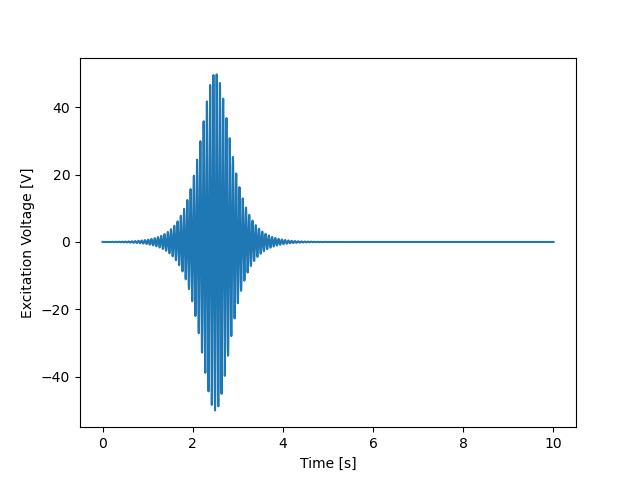

In [38]:

# def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
# 	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
t_end = 10
def v_exc(t, A_exc=50, f_exc=86.9/(2*np.pi), t_end=t_end, tau=0.3):
	t0 = t_end / 4
	envelope = 1 / np.cosh((t - t0) / tau)
	return A_exc * envelope * np.cos(2*np.pi*f_exc*t)
t_eval = np.arange(0, t_end, 1/f1/20)
plt.figure()
plt.plot(t_eval, v_exc(t_eval))
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.show()


In [ ]:

interface_idx = 4
beta = -0.3
# # ======= K_p sweep in frequency domain =======

# k0 = 4000
# kc2 = ki0 / (1 - beta)**2 
# kc1 = ki0 / (1 + beta)**2 
# S = rom.S
# K_i = np.zeros(S)
# K_i = np.zeros(S)
# for i in range(S):
# 	if i < interface_idx:
# 		K_i[i] = ki1 if i % 2 == 0 else ki2
# 	else:
# 		K_i[i] = ki2 if (i - interface_idx) % 2 == 0 else ki1

# print("K_i:", K_i, )
#%%
# x_eval = np.linspace(0, rom.p.L_b, 1000)
# x0 = np.zeros(2*N + 2*S)



K_c = 1e7

results = rom.run_time_sim(v_exc=v_exc, j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

# freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
# 										w=np.linspace(f0, f1, 1000)*2*np.pi, x_eval=x_eval)